In [100]:
import pandas as pd
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [101]:
df = pd.read_csv("../data/interim/employee_performance_clean.csv")

print("Shape del dataset:", df.shape)
display(df.head())

Shape del dataset: (14000, 20)


,employee_id,age,gender,education,department,job_level,years_at_company,years_in_current_role,monthly_salary,overtime_hours_monthly,num_projects_completed,performance_rating,training_hours_yearly,work_life_balance_score,distance_from_home_km,num_companies_worked,job_satisfaction,relationship_with_manager,stock_option_level,attrition
0,1,38.0,Female,Master,IT,3,6.3,0.2,6072.54,11,7,2,39.0,5,4.40,3,3,5,3,0
1,2,32.0,Male,Bachelor,Finance,1,3.4,3.4,3058.51,15,6,3,57.1,4,4.50,2,4,4,2,0
2,3,24.0,Female,Bachelor,Engineering,1,0.8,0.8,9270.48,5,6,5,41.1,1,44.45,2,3,1,0,1
3,4,33.0,Male,Bachelor,Sales,5,0.2,0.2,7567.36,3,8,3,21.2,2,0.70,2,5,4,1,0
4,5,51.0,Male,Bachelor,Finance,3,3.8,3.8,5621.87,5,8,4,42.6,4,6.60,3,3,4,2,1


In [102]:
list(df.columns)

['employee_id',
 'age',
 'gender',
 'education',
 'department',
 'job_level',
 'years_at_company',
 'years_in_current_role',
 'monthly_salary',
 'overtime_hours_monthly',
 'num_projects_completed',
 'performance_rating',
 'training_hours_yearly',
 'work_life_balance_score',
 'distance_from_home_km',
 'num_companies_worked',
 'job_satisfaction',
 'relationship_with_manager',
 'stock_option_level',
 'attrition']

Separar variables

In [103]:
X = df.drop(columns=["attrition"])
y = df["attrition"]

print("Distribución de clases:")
print(y.value_counts())
print(y.value_counts(normalize=True).round(3))

Distribución de clases:
attrition
0    11840
1     2160
Name: count, dtype: int64
attrition
0    0.846
1    0.154
Name: proportion, dtype: float64


In [104]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (11200, 19)
X_test: (2800, 19)
y_train: (11200,)
y_test: (2800,)


Añadir pipeline

In [105]:
preproc = joblib.load("../models/preprocessing_pipeline.pkl")

print("Pipeline de preprocesamiento cargado correctamente.")

Pipeline de preprocesamiento cargado correctamente.


Regresion logistica

Es un modelo lineal de clasificación binaria que estima la probabilidad de pertenencia a una clase. Se incluye por ser interpretable, rápido y una línea base clásica en problemas de clasificación.

In [106]:
pipe_lr = Pipeline([
    ("preproc", preproc),
    ("clf", LogisticRegression(random_state=42, max_iter=1000))
])

Arbol de deciciones

Es un modelo basado en reglas que divide iterativamente los datos según condiciones sobre las variables. Se incluye porque puede capturar relaciones no lineales y es fácil de interpretar.

In [107]:
pipe_dt = Pipeline([
    ("preproc", preproc),
    ("clf", DecisionTreeClassifier(random_state=42))
])

Random Forest

Es un ensamble de múltiples árboles de decisión entrenados sobre subconjuntos aleatorios de datos y variables. Se incluye por su robustez y por ofrecer generalmente buen desempeño sin ajustes complejos.

In [110]:
pipe_rf = Pipeline([
    ("preproc", preproc),
    ("clf", RandomForestClassifier(random_state=42))
])

SVM

Es un modelo que busca el hiperplano que mejor separa las clases maximizando el margen entre ellas. Se incluye porque puede ser eficaz en problemas de clasificación con fronteras complejas.

In [111]:
pipe_svm = Pipeline([
    ("preproc", preproc),
    ("clf", SVC())
])

KNN

Es un modelo que busca el hiperplano que mejor separa las clases maximizando el margen entre ellas. Se incluye porque puede ser eficaz en problemas de clasificación con fronteras complejas.

In [112]:
pipe_knn = Pipeline([
    ("preproc", preproc),
    ("clf", KNeighborsClassifier())
])

Entrenamiento de modelos

In [115]:
pipe_lr.fit(X_train, y_train)
pipe_dt.fit(X_train, y_train)
pipe_rf.fit(X_train, y_train)
pipe_svm.fit(X_train, y_train)
pipe_knn.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preproc', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

Evaluacion de modelos

In [113]:
def evaluar_modelo(nombre, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0)
    }

In [116]:
resultados = []

resultados.append(evaluar_modelo("Logistic Regression", pipe_lr, X_test, y_test))
resultados.append(evaluar_modelo("Decision Tree", pipe_dt, X_test, y_test))
resultados.append(evaluar_modelo("Random Forest", pipe_rf, X_test, y_test))
resultados.append(evaluar_modelo("SVM", pipe_svm, X_test, y_test))
resultados.append(evaluar_modelo("KNN", pipe_knn, X_test, y_test))

df_resultados = pd.DataFrame(resultados).sort_values(by="f1", ascending=False)

display(df_resultados)

,modelo,accuracy,precision,recall,f1
1,Decision Tree,0.722500,0.148676,0.168981,0.15818
4,KNN,0.824643,0.152941,0.030093,0.05029
0,Logistic Regression,0.845714,0.000000,0.000000,0.00000
2,Random Forest,0.845714,0.000000,0.000000,0.00000
3,SVM,0.845714,0.000000,0.000000,0.00000


Mejor modelo 

In [93]:
mejor = resultados.iloc[0]["modelo"]
print("Mejor modelo según F1:", mejor)

Mejor modelo según F1: Logistic Regression


Matriz de confusion

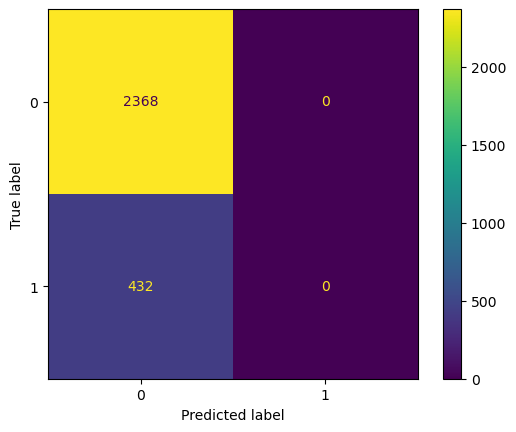

In [117]:
pred_rf = pipe_rf.predict(X_test)

cm = confusion_matrix(y_test, pred_rf)

disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

Reporte de clasificacion

In [118]:
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.85      1.00      0.92      2368
           1       0.00      0.00      0.00       432

    accuracy                           0.85      2800
   macro avg       0.42      0.50      0.46      2800
weighted avg       0.72      0.85      0.78      2800



C:\Users\Usuario\miniforge3\envs\ProjectG7\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\miniforge3\envs\ProjectG7\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Usuario\miniforge3\envs\ProjectG7\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize

Guardando modelos

In [119]:
Path("../models").mkdir(parents=True, exist_ok=True)

joblib.dump(pipe_lr, "../models/baseline_lr.pkl")
joblib.dump(pipe_dt, "../models/baseline_dt.pkl")
joblib.dump(pipe_rf, "../models/baseline_rf.pkl")
joblib.dump(pipe_svm, "../models/baseline_svm.pkl")
joblib.dump(pipe_knn, "../models/baseline_knn.pkl")

print("Modelos guardados correctamente.")

Modelos guardados correctamente.
